In [14]:
import torch
import torch.nn as nn
from torch.utils.data import ConcatDataset, Subset, DataLoader
import numpy as np

from dataset import create_dataloaders
from gan_model import MHEGAN
from train import train_one_epoch
from evaluate import evaluate, evaluate_top_models_person_cv
from grid_search import run_grid_search, run_person_grid_search

In [15]:
# params = {
#     "learning_rate": 5e-3,
#     "hidden_channels": 32,
#     "kernel_size": 3,
#     "dropout": 0.1,
#     "num_heads": 2,
#     "weight_decay": 1e-4,
#     "batch_size": 8,
# }

params = {'learning_rate': 0.005, 'hidden_channels': 64, 'kernel_size': 7, 'dropout': 0.2, 'num_heads': 2, 'weight_decay': 0.0001, 'batch_size': 8}

BATCH_SIZE = 8

INTRA_DATA_DIR = "preprocessed_data/Intra"
intra_train_loader, intra_test_loader = create_dataloaders(INTRA_DATA_DIR, BATCH_SIZE, add_person_id=True)

CROSS_DATA_DIR = "preprocessed_data/Cross"
NUM_CLASSES = 4
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

cross_train_loader, cross_test_loader = create_dataloaders(CROSS_DATA_DIR, BATCH_SIZE, add_person_id=True)

Loading test data...
Loading train data...
Loaded 32 training samples
Loaded 8 test samples
Class distribution in training: [8 8 8 8]
Class distribution in test: [2 2 2 2]
Train batches: 4
Test batches: 1
Using device: cuda
Loading test1 data...
Loading test2 data...
Loading test3 data...
Loading train data...
Loaded 64 training samples
Loaded 48 test samples
Class distribution in training: [16 16 16 16]
Class distribution in test: [12 12 12 12]
Train batches: 8
Test batches: 6


In [16]:
cross_dataset = cross_train_loader.dataset
intra_dataset = intra_train_loader.dataset

def build_person_subsets(dataset, source_name):
    """Build subsets of the dataset grouped by person_id."""
    if dataset.person_ids is None:
        raise ValueError(f"{source_name} dataset must be created with add_person_id=True")

    grouped_indices = {}
    for index, person_id in enumerate(dataset.person_ids):
        grouped_indices.setdefault(int(person_id), []).append(index)

    return [
        (f"{source_name}_{person_id}", Subset(dataset, indices), person_id)
        for person_id, indices in sorted(grouped_indices.items())
    ]


cross_person_splits = build_person_subsets(cross_dataset, "cross")
intra_person_splits = build_person_subsets(intra_dataset, "intra")
person_splits = cross_person_splits + intra_person_splits

print("Person-level folds:")
for split_name, subset, person_id in person_splits:
    print(f"  {split_name}: person_id={person_id}, samples={len(subset)}")

Person-level folds:
  cross_113922: person_id=113922, samples=32
  cross_164636: person_id=164636, samples=32
  intra_105923: person_id=105923, samples=32


In [17]:
train_dataset = ConcatDataset([subset for _, subset, _ in person_splits])
train_loader = DataLoader(
    train_dataset,
    batch_size=params["batch_size"],
    shuffle=True,
)
# validation_dataset = ConcatDataset([subset for _, subset, _ in intra_person_splits])
# validation_loader = DataLoader(
#     validation_dataset,
#     batch_size=params["batch_size"],
#     shuffle=False,
# )

model_kwargs = {
    "hidden_channels": params["hidden_channels"],
    "kernel_size": params["kernel_size"],
    "dropout": params["dropout"],
    "num_heads": params["num_heads"],
    "num_classes": NUM_CLASSES,
}

PATIENCE = 8

average_results = []
best_run_index = -1
best_run_score = float("-inf")
best_model_state = None
best_model_result = None

for run in range(10):
    model = MHEGAN(**model_kwargs).to(DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=params["learning_rate"],
        weight_decay=params["weight_decay"],
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        patience=max(1, PATIENCE // 2),
        factor=0.5,
    )

    num_epochs = params.get("epochs", 25)
    # best_val_loss = float("inf")
    # best_val_acc = 0.0
    # best_state_dict = None
    # bad_epochs = 0

    # min_delta = 1e-4


    for epoch in range(num_epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
        scheduler.step(train_loss)

        # val_loss, val_acc = evaluate(model, validation_loader, criterion, DEVICE)
        # scheduler.step(val_loss)

        # # Keep the checkpoint with the lowest validation loss.
        # if val_loss < best_val_loss - min_delta:
        #     best_val_loss = val_loss
        #     best_val_acc = val_acc
        #     best_state_dict = {
        #         key: value.detach().cpu().clone()
        #         for key, value in model.state_dict().items()
        #     }
        #     bad_epochs = 0
        # else:
        #     bad_epochs += 1

        # Evaluate on cross test set
        #test_loss, test_acc = evaluate(model, cross_test_loader, criterion, DEVICE)
        print(f"Epoch {epoch + 1}/{num_epochs} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
        # print(f"Epoch {epoch + 1}/{num_epochs} | Train Acc: {train_acc:.2f} | Train Loss: {train_loss:.4f} | Val Acc: {val_acc:.2f} | Val Loss: {val_loss:.4f}")

        # # Stop once validation loss has not improved for several epochs.
        # if bad_epochs >= PATIENCE:
        #     print(
        #         f"Early stopping at epoch {epoch + 1} after {PATIENCE} "
        #         "non-improving epochs."
        #     )
        #     break
        

    test_result = evaluate(model, cross_test_loader, criterion, DEVICE)
    print(f"Cross test result: {test_result}")
    average_results.append(test_result)

    if test_result[1] > best_run_score:
        best_run_score = test_result[1]
        best_run_index = run
        best_model_result = test_result
        best_model_state = {
            key: value.detach().cpu().clone()
            for key, value in model.state_dict().items()
        }
        best_model = model

average_loss = np.mean([result[0] for result in average_results])
average_acc = np.mean([result[1] for result in average_results])
stdev_loss = np.std([result[0] for result in average_results])
stdev_acc = np.std([result[1] for result in average_results])

print(f"Average Loss: {average_loss:.4f} ± {stdev_loss:.4f}")
print(f"Average Accuracy: {average_acc:.2f}% ± {stdev_acc:.2f}%")

# best_model = MHEGAN(**model_kwargs).to(DEVICE)
# if best_model_state is not None:
#     best_model.load_state_dict(best_model_state)
#     best_model.eval()
#     print(f"Best run: {best_run_index + 1} | Best test result: {best_model_result}")

Epoch 1/25 | Train Loss: 0.9087 | Train Acc: 59.38%
Epoch 2/25 | Train Loss: 0.4416 | Train Acc: 85.42%
Epoch 3/25 | Train Loss: 0.2113 | Train Acc: 91.67%
Epoch 4/25 | Train Loss: 0.2893 | Train Acc: 91.67%
Epoch 5/25 | Train Loss: 0.1920 | Train Acc: 91.67%
Epoch 6/25 | Train Loss: 0.2690 | Train Acc: 89.58%
Epoch 7/25 | Train Loss: 0.2608 | Train Acc: 93.75%
Epoch 8/25 | Train Loss: 0.0551 | Train Acc: 98.96%
Epoch 9/25 | Train Loss: 0.1520 | Train Acc: 95.83%
Epoch 10/25 | Train Loss: 0.2313 | Train Acc: 92.71%
Epoch 11/25 | Train Loss: 0.1455 | Train Acc: 97.92%
Epoch 12/25 | Train Loss: 0.0430 | Train Acc: 97.92%
Epoch 13/25 | Train Loss: 0.0497 | Train Acc: 97.92%
Epoch 14/25 | Train Loss: 0.0468 | Train Acc: 98.96%
Epoch 15/25 | Train Loss: 0.1256 | Train Acc: 95.83%
Epoch 16/25 | Train Loss: 0.1780 | Train Acc: 94.79%
Epoch 17/25 | Train Loss: 0.0357 | Train Acc: 98.96%
Epoch 18/25 | Train Loss: 0.0988 | Train Acc: 96.88%
Epoch 19/25 | Train Loss: 0.0519 | Train Acc: 98.96%
Ep

In [18]:
test_result = evaluate(best_model, cross_test_loader, criterion, DEVICE)
print(f"Cross test result: {test_result}")

Cross test result: (4.785801023244858, 68.75)


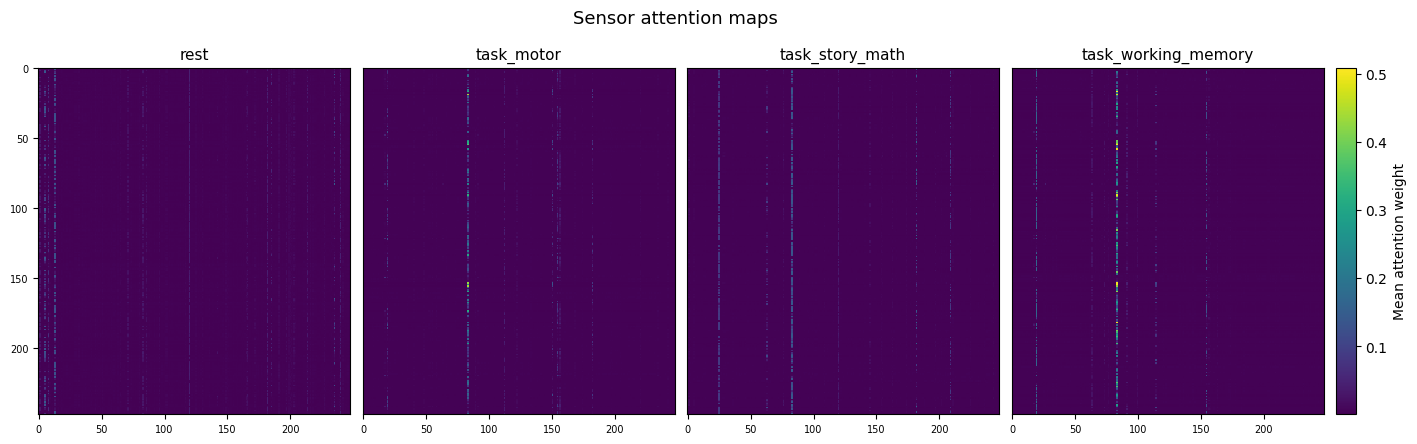

Saved → sensor_attention_maps.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import defaultdict
from dataset import CLASS_NAMES

# ── 1. Collect attention weights per class ────────────────────────────────────
class_attns = defaultdict(list)

model = best_model

model.eval()
with torch.no_grad():
    for batch in cross_test_loader:
        x_batch = batch[0].to(DEVICE)
        y_batch = batch[1].to(DEVICE)

        _ = model(x_batch)
        attn = model.get_attention_weights()          # (B, H, N, N)
        attn_avg = attn.mean(dim=1).cpu().numpy()     # (B, N, N) — average over heads

        for i in range(attn_avg.shape[0]):
            label = CLASS_NAMES[y_batch[i].item()]
            class_attns[label].append(attn_avg[i])

# ── 2. Compute per-class mean maps ────────────────────────────────────────────
sorted_labels  = sorted(class_attns.keys())
mean_maps      = {label: np.stack(class_attns[label]).mean(axis=0)
                  for label in sorted_labels}

# All-class average
all_maps = np.concatenate(list(class_attns.values()), axis=0)
#mean_maps["all"] = all_maps.mean(axis=0)
#sorted_labels = ["all"] + sorted_labels  # prepend so it appears first

# Shared colour range across all classes so maps are directly comparable
vmin = min(m.min() for m in mean_maps.values())
vmax = max(m.max() for m in mean_maps.values())

# ── 3. Plot ───────────────────────────────────────────────────────────────────
n_classes   = len(sorted_labels)
class_names = {i: f"{i}" for i in sorted_labels}
# class_names["all"] = "all"

fig = plt.figure(figsize=(4 * n_classes + 1, 4.5))
gs  = gridspec.GridSpec(
    1, n_classes + 1,
    width_ratios=[4] * n_classes + [0.25],   # last column = colourbar
    wspace=0.05,
)

axes = [fig.add_subplot(gs[0, j]) for j in range(n_classes)]
cax  =  fig.add_subplot(gs[0, n_classes])

for ax, label in zip(axes, sorted_labels):
    im = ax.imshow(
        mean_maps[label],
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
        aspect="auto",
        interpolation="nearest",
    )
    ax.set_title(class_names[label], fontsize=11, pad=6)
    # ax.set_xlabel("Sensor (key)", fontsize=8)
    if ax is axes[0]:
        # ax.set_ylabel("Sensor (query)", fontsize=8)
        pass
    else:
        ax.set_yticks([])           # hide redundant y-ticks on subsequent panels

    # Optional: thin tick marks every 50 sensors
    ticks = np.arange(0, mean_maps[label].shape[0], 50)
    ax.set_xticks(ticks)
    ax.set_xticklabels(ticks, fontsize=7)
    if ax is axes[0]:
        ax.set_yticks(ticks)
        ax.set_yticklabels(ticks, fontsize=7)

fig.colorbar(im, cax=cax, label="Mean attention weight")
fig.suptitle("Sensor attention maps", fontsize=13, y=1.01)
plt.savefig("results/sensor_attention_maps.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → sensor_attention_maps.png")

In [20]:
print(f"graph_gate: {model.graph_gate.item():.3f}  "
      f"sigmoid: {torch.sigmoid(model.graph_gate).item():.3f}")

graph_gate: -0.129  sigmoid: 0.468


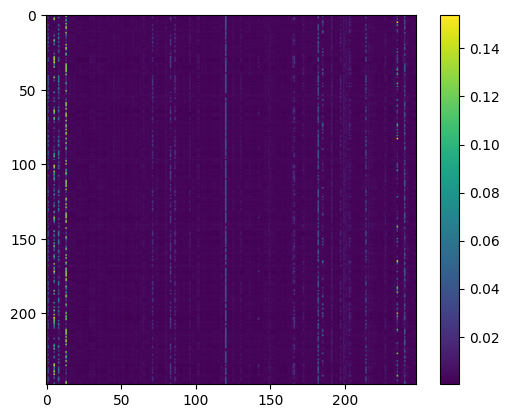

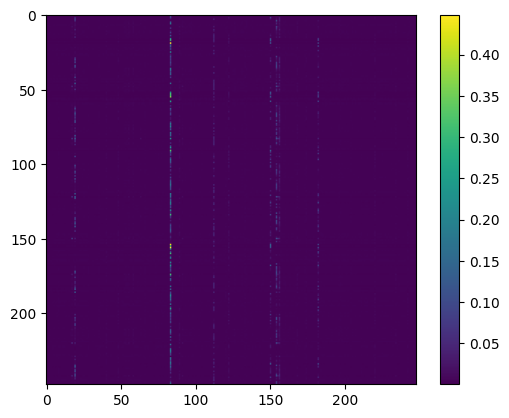

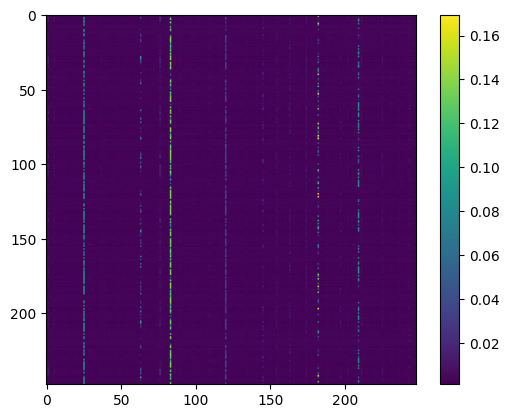

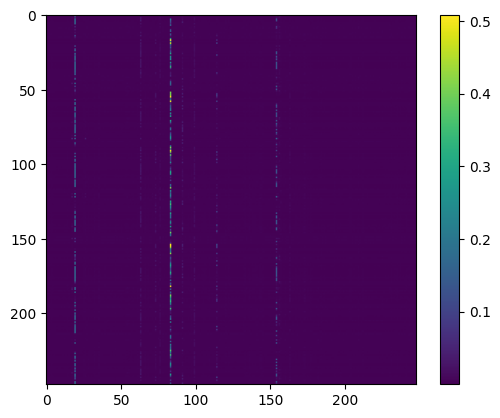

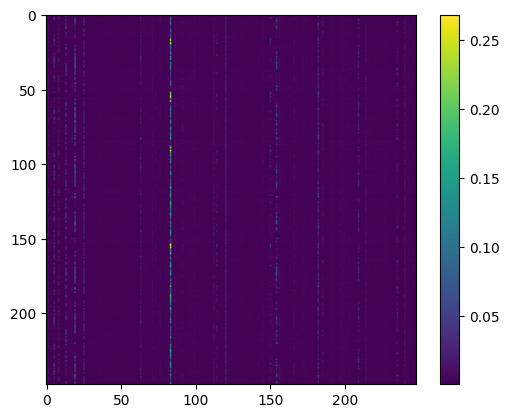

In [21]:
from collections import defaultdict
import matplotlib.pyplot as plt

class_attns = defaultdict(list)

model.eval()
with torch.no_grad():
    #for x_batch, y_batch in cross_test_loader:
    for batch in cross_test_loader:
        x_batch = batch[0].to(DEVICE)
        y_batch = batch[1].to(DEVICE)
        _ = model(x_batch)
        attn = model.get_attention_weights()          # (B, H, N, N)
        attn_avg = attn.mean(dim=(1,)).cpu().numpy()  # (B, N, N) — keep batch dim
        for i in range(attn_avg.shape[0]):
            label = y_batch[i].item()
            class_attns[label].append(attn_avg[i])

# Average per class
for label, maps in class_attns.items():
    mean_map = np.stack(maps).mean(axis=0)           # (N, N)
    plt.imshow(mean_map, cmap="viridis")
    plt.colorbar()
    plt.show()

# All classes combined
all_maps = np.concatenate([np.stack(maps) for maps in class_attns.values()], axis=0)  # (total_samples, N, N)
mean_map = all_maps.mean(axis=0)  # (N, N)
plt.imshow(mean_map, cmap="viridis")
plt.colorbar()
plt.show()

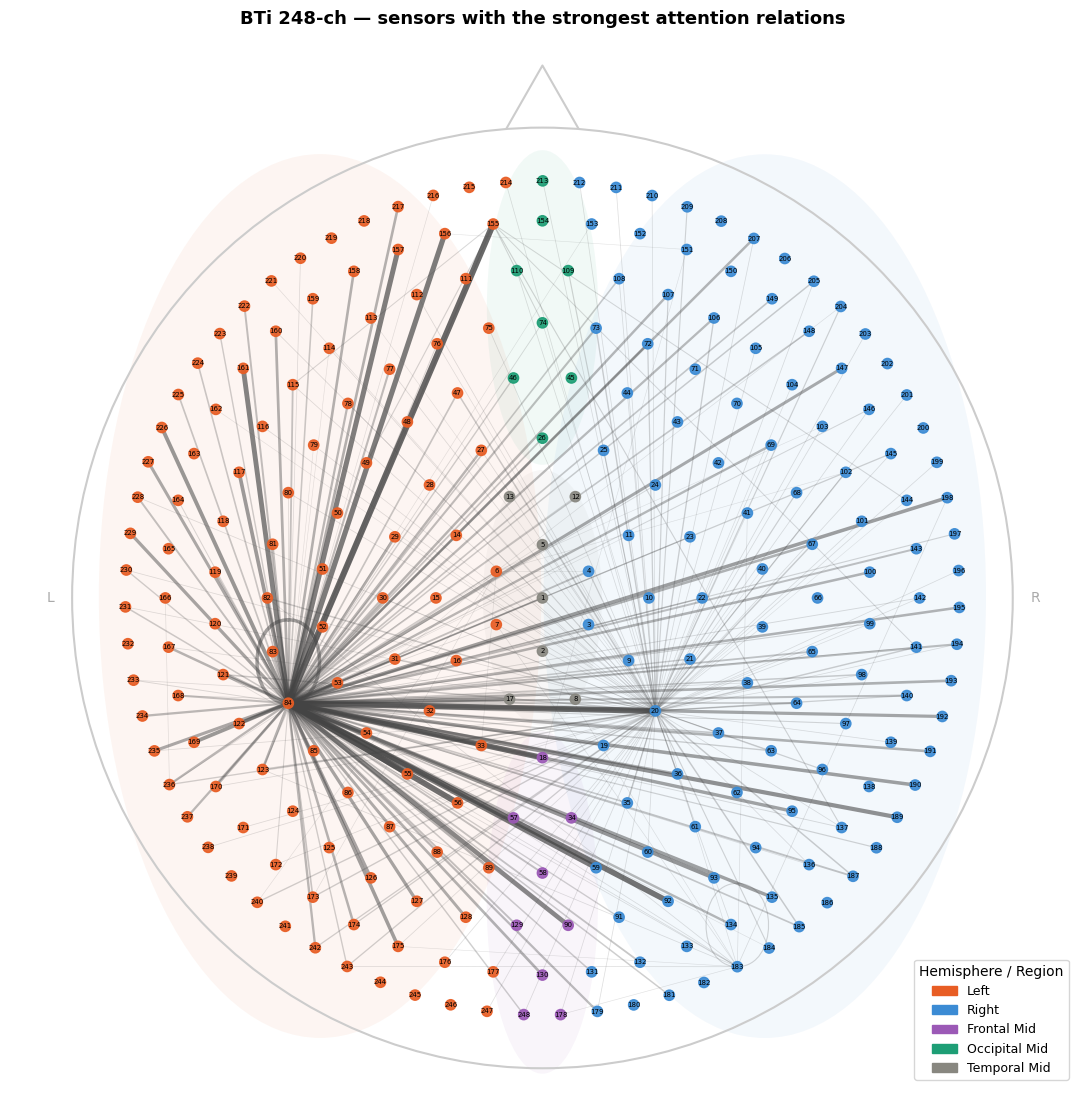

In [22]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

TOP_N_EDGES = 300

# ── 1. BTi 248-channel scalp projection layout ──────────────────────────────
def make_bti248_positions():
    """
    2D scalp projection for the BTi/4D Neuroimaging 248-sensor helmet.
    Returns a dict {sensor_idx: (x, y)} in normalized [-1, 1] space.
    Nose points up (negative y), left hemisphere on the left (negative x).
    """
    rings = [
        dict(r=0.00, count=1,  offset=0.0),
        dict(r=0.12, count=6,  offset=0.0),
        dict(r=0.24, count=10, offset=18.0),
        dict(r=0.36, count=16, offset=0.0),
        dict(r=0.50, count=24, offset=7.5),
        dict(r=0.62, count=32, offset=0.0),
        dict(r=0.74, count=40, offset=4.5),
        dict(r=0.85, count=48, offset=0.0),
        dict(r=0.94, count=71, offset=2.5),
    ]
    positions = {}
    idx = 0
    for ring in rings:
        n, r, offset = ring["count"], ring["r"], ring["offset"]
        for i in range(n):
            if idx >= 248:
                break
            angle_deg = offset + (360.0 / n) * i
            angle_rad = np.deg2rad(angle_deg)
            x =  r * np.sin(angle_rad)   # left = negative x
            y = -r * np.cos(angle_rad)   # nose up = negative y
            positions[idx] = (x, y)
            idx += 1
        if idx >= 248:
            break
    return positions

def get_sensor_region(x, y):
    """Assign each sensor to a hemisphere / midline region."""
    if abs(x) < 0.08:
        if y < -0.3:   return "frontal_mid"
        if y >  0.3:   return "occipital_mid"
        return "temporal_mid"
    return "left" if x < 0 else "right"

REGION_COLORS = {
    "left":          "#E85D24",   # warm orange-red
    "right":         "#3B8BD4",   # blue
    "frontal_mid":   "#9B59B6",   # purple
    "occipital_mid": "#1D9E75",   # teal-green
    "temporal_mid":  "#888780",   # gray
}

sensor_positions = make_bti248_positions()   # {idx: (x, y)}
sensor_regions   = {i: get_sensor_region(x, y)
                    for i, (x, y) in sensor_positions.items()}

# ── 2. Build graph (same logic as before) ───────────────────────────────────
def get_top_relations(attention_map, top_k=20):
    flat_indices = np.argsort(attention_map.flatten())[-top_k:]
    relations    = np.unravel_index(flat_indices, attention_map.shape)
    values       = attention_map[relations]
    return list(zip(relations[0], relations[1], values))

edge_weights = {}
for label in sorted_labels:
    for src, dst, weight in get_top_relations(mean_maps[label], top_k=248):
        key = (src, dst)
        edge_weights[key] = edge_weights.get(key, 0) + weight

top_edges = sorted(edge_weights.items(), key=lambda x: x[1], reverse=True)[:TOP_N_EDGES]

graph = nx.Graph()
graph.add_nodes_from(range(248))
graph.add_weighted_edges_from(
    [(s, d, w) for (s, d), w in edge_weights.items()
     if (s, d) in dict(top_edges)]
)

focus_nodes = sorted(set(
    n for (s, d), _ in top_edges for n in (s, d)
))
subgraph = graph

# ── 3. Draw with topographic positions ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 11))

# Head circle + nose indicator
head = plt.Circle((0, 0), 1.06, fill=False, color="#cccccc", linewidth=1.5)
ax.add_patch(head)
nose_x = [-.08, 0, .08]
nose_y = [1.06, 1.20, 1.06]
ax.plot(nose_x, nose_y, color="#cccccc", linewidth=1.5)
ax.text(-1.10, 0, "L", ha="right", va="center", fontsize=10, color="#aaaaaa")
ax.text( 1.10, 0, "R", ha="left",  va="center", fontsize=10, color="#aaaaaa")

# Scale positions from [-1,1] to canvas (no further transform needed)
pos_sub  = sensor_positions
pos_all  = sensor_positions          # all 248 for background dots

# Background dots (inactive sensors)
all_inactive = [n for n in range(248) if n not in subgraph.nodes()]
ax.scatter(
    [sensor_positions[n][0] for n in all_inactive],
    [sensor_positions[n][1] for n in all_inactive],
    s=8, color="#cccccc", alpha=0.35, zorder=1
)

# Region shading (subtle ellipses per hemisphere)
from matplotlib.patches import Ellipse
for region, color in REGION_COLORS.items():
    rn = [i for i, r in sensor_regions.items() if r == region]
    if not rn:
        continue
    xs = [sensor_positions[i][0] for i in rn]
    ys = [sensor_positions[i][1] for i in rn]
    mx, my = np.mean(xs), np.mean(ys)
    rx = max(abs(np.array(xs) - mx)) + 0.06
    ry = max(abs(np.array(ys) - my)) + 0.06
    ellipse = Ellipse((mx, my), width=2*rx, height=2*ry,
                      facecolor=color, alpha=0.06, zorder=0)
    ax.add_patch(ellipse)

# Edges
w_vals = np.array([subgraph[u][v]["weight"] for u, v in subgraph.edges()])
if len(w_vals):
    w_min, w_max = w_vals.min(), w_vals.max()
    w_norm = (w_vals - w_min) / (w_max - w_min + 1e-9)
else:
    w_norm = w_vals

nx.draw_networkx_edges(
    subgraph, pos_sub, ax=ax,
    width=[0.4 + 4.0 * w for w in w_norm],
    alpha=[0.15 + 0.65 * w for w in w_norm],
    edge_color="#444444",
)

# Nodes — colored by hemisphere/region
node_colors = [REGION_COLORS[sensor_regions[n]] for n in subgraph.nodes()]
nx.draw_networkx_nodes(
    subgraph, pos_sub, ax=ax,
    node_size=55,
    node_color=node_colors,
    alpha=0.92,
)

# Optional: sensor labels (uncomment for debugging)
nx.draw_networkx_labels(subgraph, pos_sub, ax=ax,
    labels={n: str(n + 1) for n in subgraph.nodes()},
    font_size=5, font_color="black")

# Legend
legend_handles = [
    mpatches.Patch(color=c, label=r.replace("_", " ").title())
    for r, c in REGION_COLORS.items()
]
ax.legend(handles=legend_handles, loc="lower right",
          fontsize=9, framealpha=0.8, title="Hemisphere / Region")

ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.1, 1.25)
ax.set_aspect("equal")
ax.axis("off")
ax.set_title("BTi 248-ch — sensors with the strongest attention relations",
             fontsize=13, fontweight="bold", pad=14)
plt.tight_layout()
plt.show()

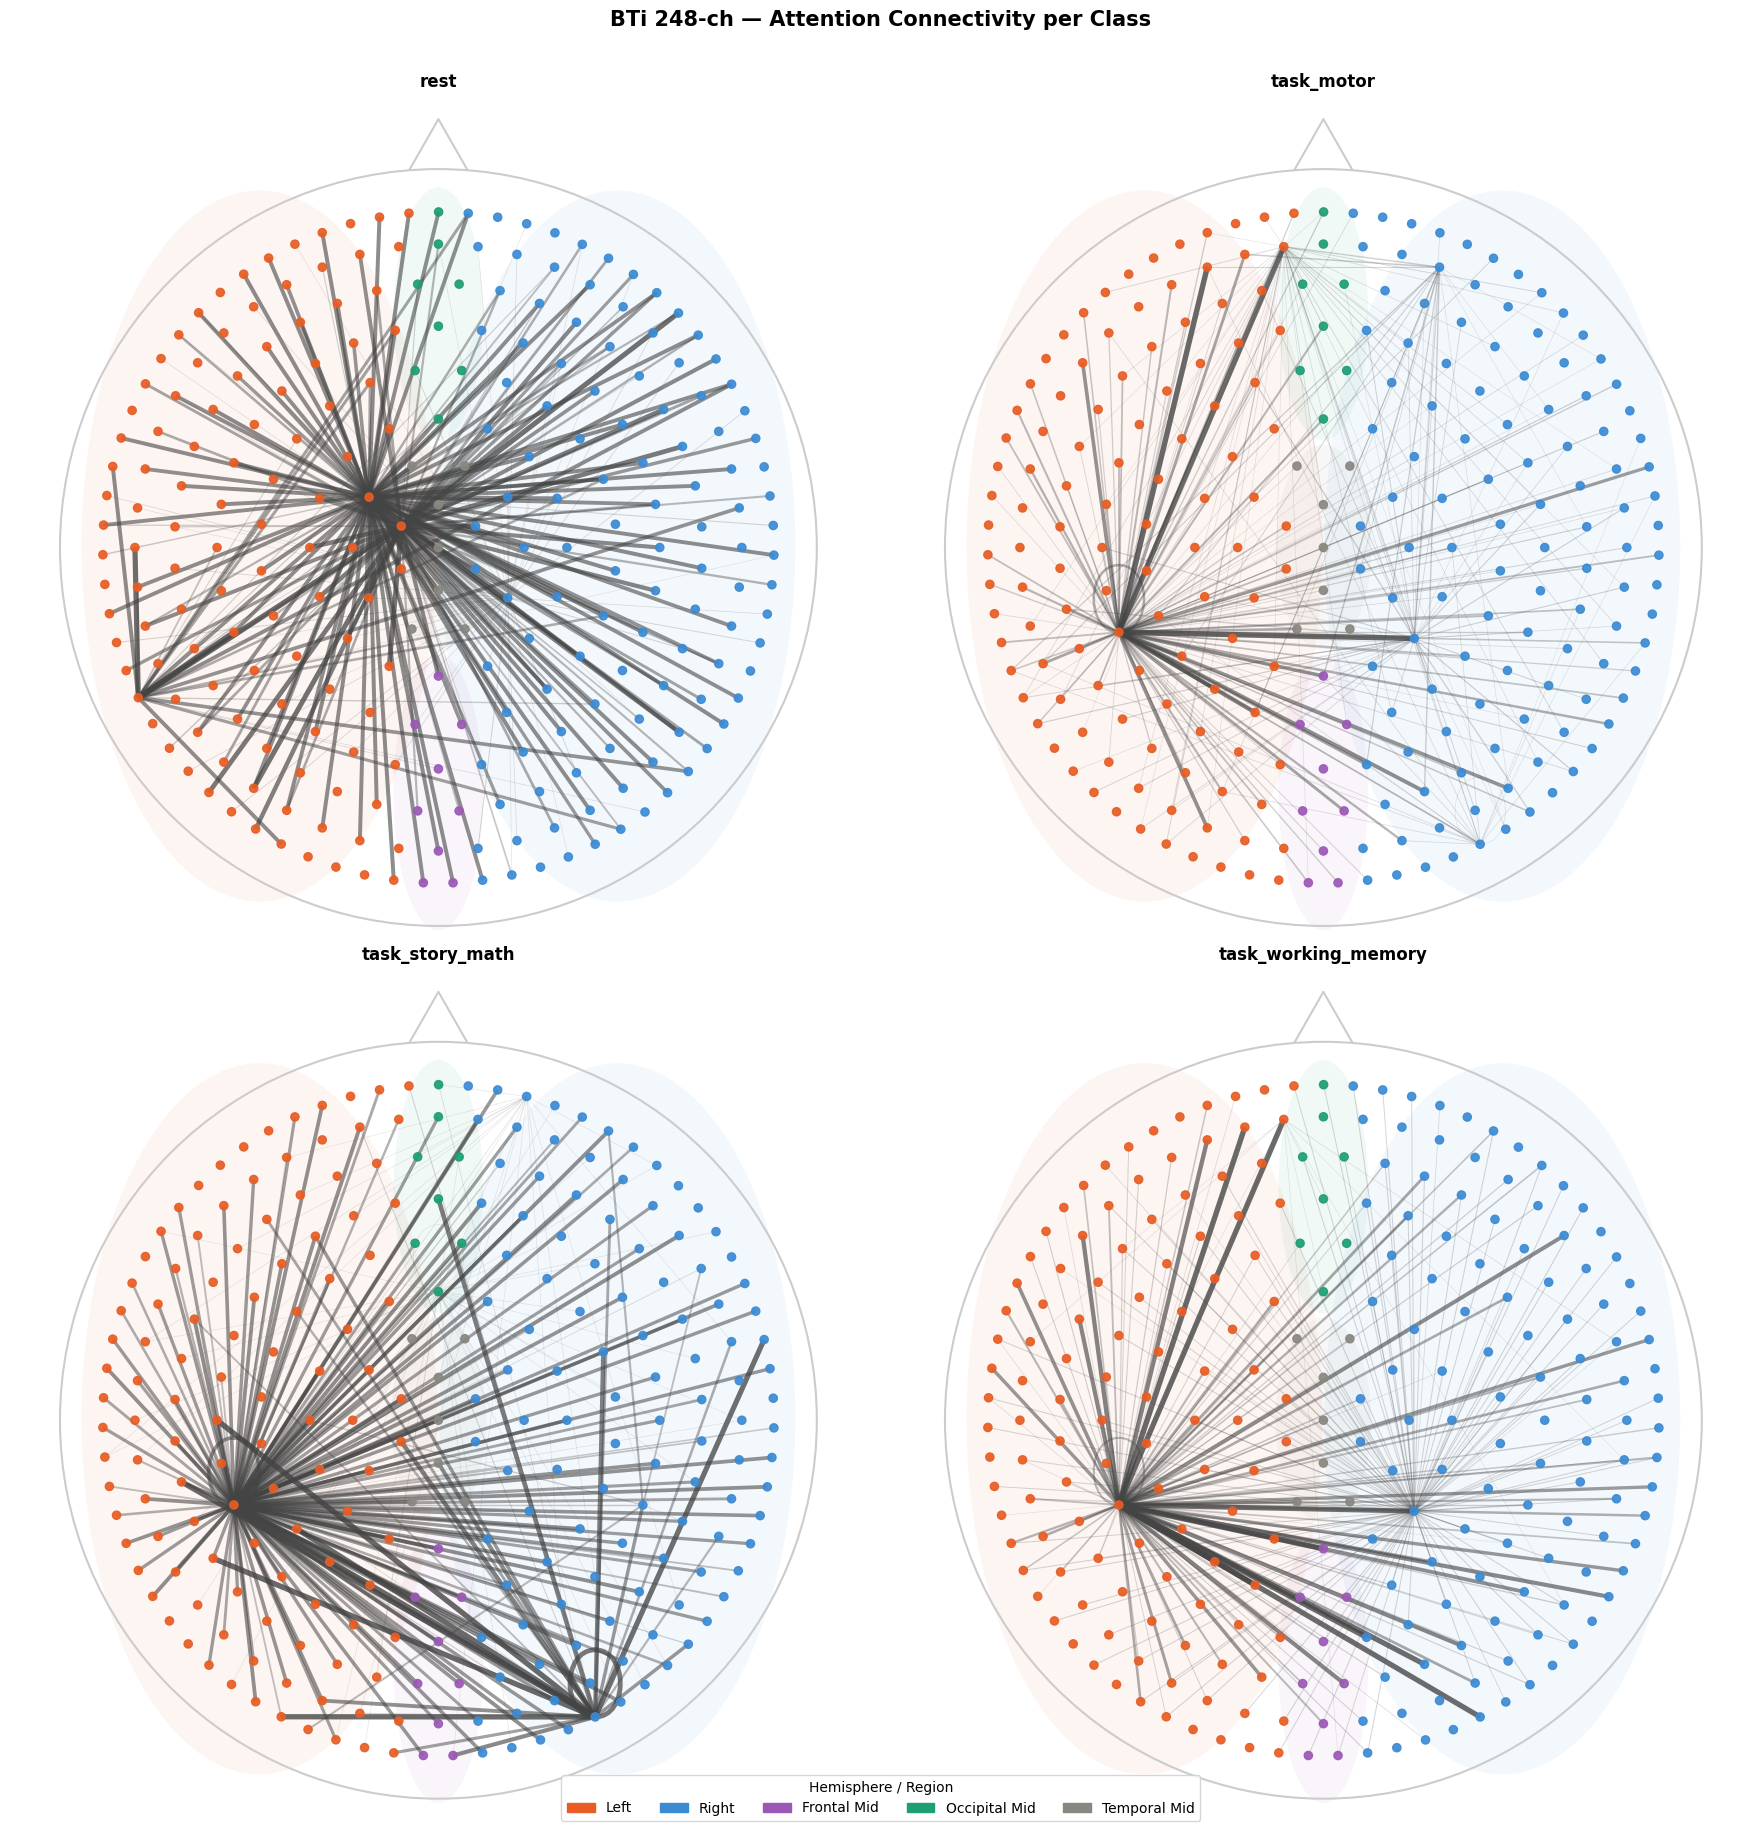

In [ ]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Ellipse
from collections import defaultdict
import torch
from dataset import CLASS_NAMES

TOP_N_EDGES = 300

# ── 1. BTi 248-channel scalp projection layout ──────────────────────────────
def make_bti248_positions():
    rings = [
        dict(r=0.00, count=1,  offset=0.0),
        dict(r=0.12, count=6,  offset=0.0),
        dict(r=0.24, count=10, offset=18.0),
        dict(r=0.36, count=16, offset=0.0),
        dict(r=0.50, count=24, offset=7.5),
        dict(r=0.62, count=32, offset=0.0),
        dict(r=0.74, count=40, offset=4.5),
        dict(r=0.85, count=48, offset=0.0),
        dict(r=0.94, count=71, offset=2.5),
    ]
    positions = {}
    idx = 0
    for ring in rings:
        n, r, offset = ring["count"], ring["r"], ring["offset"]
        for i in range(n):
            if idx >= 248:
                break
            angle_deg = offset + (360.0 / n) * i
            angle_rad = np.deg2rad(angle_deg)
            x =  r * np.sin(angle_rad)
            y = -r * np.cos(angle_rad)
            positions[idx] = (x, y)
            idx += 1
        if idx >= 248:
            break
    return positions

def get_sensor_region(x, y):
    if abs(x) < 0.08:
        if y < -0.3:   return "frontal_mid"
        if y >  0.3:   return "occipital_mid"
        return "temporal_mid"
    return "left" if x < 0 else "right"

REGION_COLORS = {
    "left":          "#E85D24",
    "right":         "#3B8BD4",
    "frontal_mid":   "#9B59B6",
    "occipital_mid": "#1D9E75",
    "temporal_mid":  "#888780",
}

sensor_positions = make_bti248_positions()
sensor_regions   = {i: get_sensor_region(x, y)
                    for i, (x, y) in sensor_positions.items()}

# ── 2. Collect attention maps per class ─────────────────────────────────────
class_attns = defaultdict(list)
model.eval()
with torch.no_grad():
    for batch in cross_test_loader:
        x_batch = batch[0].to(DEVICE)
        y_batch = batch[1].to(DEVICE)
        _ = model(x_batch)
        attn = model.get_attention_weights()          # (B, H, N, N)
        attn_avg = attn.mean(dim=1).cpu().numpy()     # (B, N, N)
        for i in range(attn_avg.shape[0]):
            label = y_batch[i].item()
            class_attns[label].append(attn_avg[i])

# Average attention map per class
mean_maps = {
    label: np.stack(maps).mean(axis=0)               # (N, N)
    for label, maps in class_attns.items()
}

# ── 3. Helper: build graph from a single mean attention map ─────────────────
def get_top_relations(attention_map, top_k=248):
    flat_indices = np.argsort(attention_map.flatten())[-top_k:]
    relations    = np.unravel_index(flat_indices, attention_map.shape)
    values       = attention_map[relations]
    return list(zip(relations[0], relations[1], values))

def build_graph_for_label(mean_map, top_n_edges=TOP_N_EDGES):
    edge_weights = {}
    for src, dst, weight in get_top_relations(mean_map, top_k=248):
        key = (src, dst)
        edge_weights[key] = edge_weights.get(key, 0) + weight

    top_edges = sorted(edge_weights.items(), key=lambda x: x[1], reverse=True)[:top_n_edges]
    top_edge_set = set(dict(top_edges).keys())

    graph = nx.Graph()
    graph.add_nodes_from(range(248))
    graph.add_weighted_edges_from(
        [(s, d, w) for (s, d), w in edge_weights.items() if (s, d) in top_edge_set]
    )
    return graph, top_edges

# ── 4. Helper: draw one topographic graph onto an Axes ──────────────────────
def draw_topo_graph(ax, graph, title):
    # Head circle + nose
    head = plt.Circle((0, 0), 1.06, fill=False, color="#cccccc", linewidth=1.5)
    ax.add_patch(head)
    ax.plot([-.08, 0, .08], [1.06, 1.20, 1.06], color="#cccccc", linewidth=1.5)
    #ax.text(-1.10, 0, "L", ha="right", va="center", fontsize=9, color="#aaaaaa")
    #ax.text( 1.10, 0, "R", ha="left",  va="center", fontsize=9, color="#aaaaaa")

    # Inactive (background) sensors
    all_inactive = [n for n in range(248) if n not in graph.nodes()
                    or graph.degree(n) == 0]
    ax.scatter(
        [sensor_positions[n][0] for n in all_inactive],
        [sensor_positions[n][1] for n in all_inactive],
        s=6, color="#cccccc", alpha=0.35, zorder=1
    )

    # Region shading
    for region, color in REGION_COLORS.items():
        rn = [i for i, r in sensor_regions.items() if r == region]
        if not rn:
            continue
        xs = [sensor_positions[i][0] for i in rn]
        ys = [sensor_positions[i][1] for i in rn]
        mx, my = np.mean(xs), np.mean(ys)
        rx = max(abs(np.array(xs) - mx)) + 0.06
        ry = max(abs(np.array(ys) - my)) + 0.06
        ax.add_patch(Ellipse((mx, my), width=2*rx, height=2*ry,
                             facecolor=color, alpha=0.06, zorder=0))

    # Edges
    w_vals = np.array([graph[u][v]["weight"] for u, v in graph.edges()])
    if len(w_vals):
        w_min, w_max = w_vals.min(), w_vals.max()
        w_norm = (w_vals - w_min) / (w_max - w_min + 1e-9)
    else:
        w_norm = w_vals

    nx.draw_networkx_edges(
        graph, sensor_positions, ax=ax,
        width=[0.4 + 3.5 * w for w in w_norm],
        alpha=[0.15 + 0.65 * w for w in w_norm],
        edge_color="#444444",
    )

    # Nodes
    node_colors = [REGION_COLORS[sensor_regions[n]] for n in graph.nodes()]
    nx.draw_networkx_nodes(
        graph, sensor_positions, ax=ax,
        node_size=35,
        node_color=node_colors,
        alpha=0.92,
    )

    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-1.1, 1.25)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title, fontsize=12, fontweight="bold", pad=10)

# ── 5. Plot 2×2 grid ─────────────────────────────────────────────────────────
#CLASS_NAMES = {0: "Class 0", 1: "Class 1", 2: "Class 2", 3: "Class 3"}
# Override with your actual label names, e.g.:
# CLASS_NAMES = {0: "Rest", 1: "Left Hand", 2: "Right Hand", 3: "Feet"}

sorted_labels = sorted(mean_maps.keys())[:4]   # ensure at most 4

fig, axes = plt.subplots(2, 2, figsize=(18, 18))
axes = axes.flatten()

for ax, label in zip(axes, sorted_labels):
    graph, _ = build_graph_for_label(mean_maps[label], top_n_edges=TOP_N_EDGES)
    draw_topo_graph(ax, graph, title=f"{CLASS_NAMES[label]}")

# Shared legend on the figure
legend_handles = [
    mpatches.Patch(color=c, label=r.replace("_", " ").title())
    for r, c in REGION_COLORS.items()
]
fig.legend(handles=legend_handles, loc="lower center", ncol=5,
           fontsize=10, framealpha=0.8, title="Hemisphere / Region",
           bbox_to_anchor=(0.5, 0))

fig.suptitle("BTi 248-ch — Attention Connectivity per Class",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
fig.subplots_adjust(wspace=0)
plt.savefig("results/class_attention_graphs.png", dpi=150, bbox_inches="tight")
plt.show()

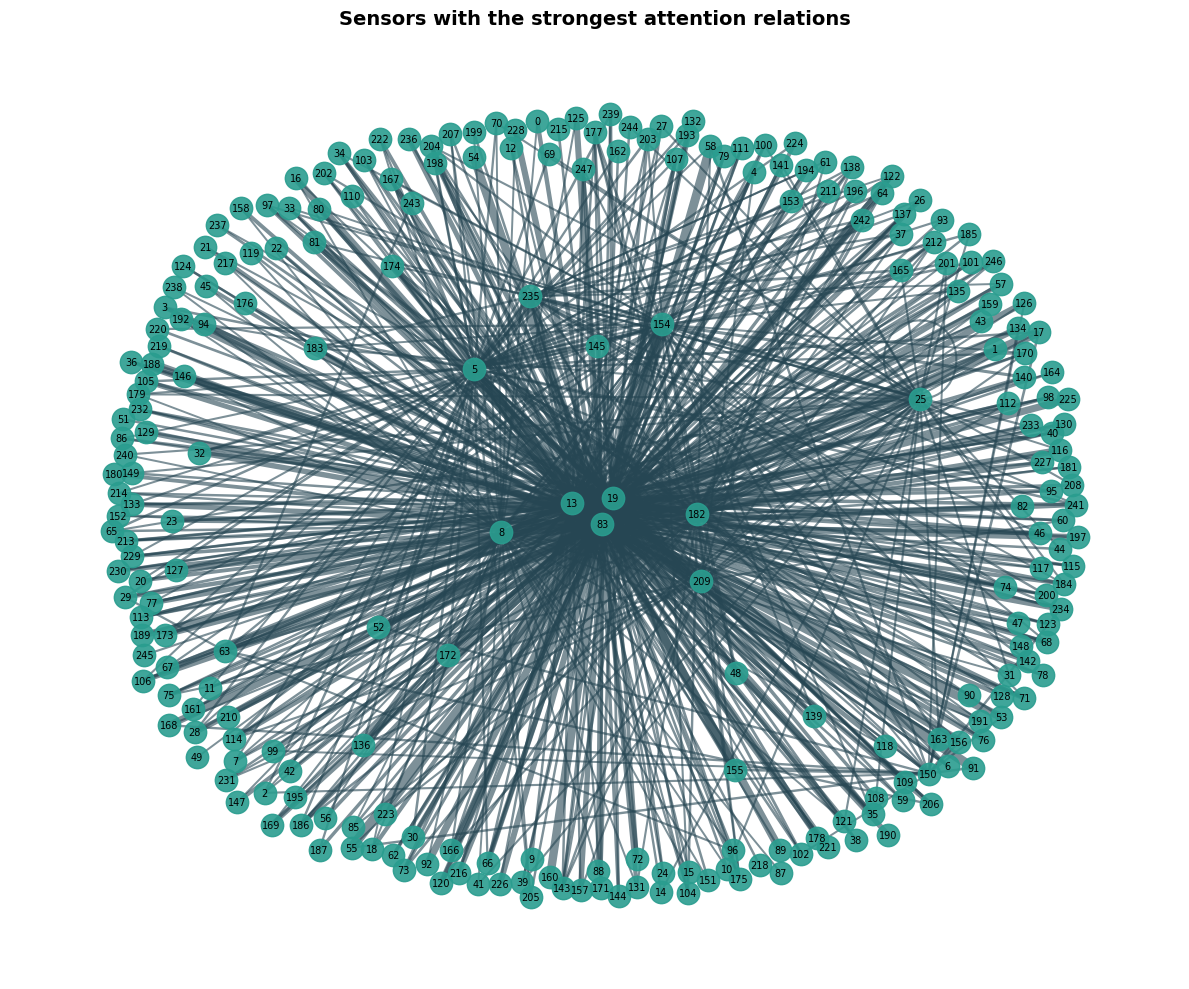

In [24]:
import numpy as np
import networkx as nx

import matplotlib.pyplot as plt

# Extract top sensor relations from mean attention maps
def get_top_relations(attention_map, top_k=20):
    """Extract top-k attention relations from the attention map."""
    flat_indices = np.argsort(attention_map.flatten())[-top_k:]
    relations = np.unravel_index(flat_indices, attention_map.shape)
    values = attention_map[relations]
    return list(zip(relations[0], relations[1], values))

# Build graph with top relations from all classes
G = nx.DiGraph()
edge_weights = {}

for label in sorted_labels:
    top_relations = get_top_relations(mean_maps[label], top_k=248)
    for src, dst, weight in top_relations:
        edge_id = (src, dst)
        if edge_id in edge_weights:
            edge_weights[edge_id] += weight
        else:
            edge_weights[edge_id] = weight
        G.add_edge(src, dst, weight=weight)

# Filter to top edges by accumulated weight
top_edges = sorted(edge_weights.items(), key=lambda x: x[1], reverse=True)

graph = nx.Graph()
graph.add_nodes_from(range(mean_maps[sorted_labels[0]].shape[0]))  # assuming all maps have same shape
graph.add_weighted_edges_from([(src, dst, weight) for (src, dst), weight in edge_weights.items()])


focus_nodes = sorted(set([src for (src, dst), _ in top_edges] + [dst for (src, dst), _ in top_edges]))
subgraph = graph.subgraph(focus_nodes).copy()

plt.figure(figsize=(12, 10))
positions = nx.spring_layout(subgraph, seed=42, k=0.8)
edge_widths = [1.0 + 6.0 * subgraph[u][v]["weight"] for u, v in subgraph.edges()]
nx.draw_networkx_nodes(subgraph, positions, node_size=260, node_color="#2a9d8f", alpha=0.9)
nx.draw_networkx_edges(subgraph, positions, width=edge_widths, alpha=0.6, edge_color="#264653")
nx.draw_networkx_labels(subgraph, positions, font_size=7, font_color="black")
plt.title("Sensors with the strongest attention relations", fontsize=14, fontweight='bold')
plt.axis("off")
plt.tight_layout()
plt.show()

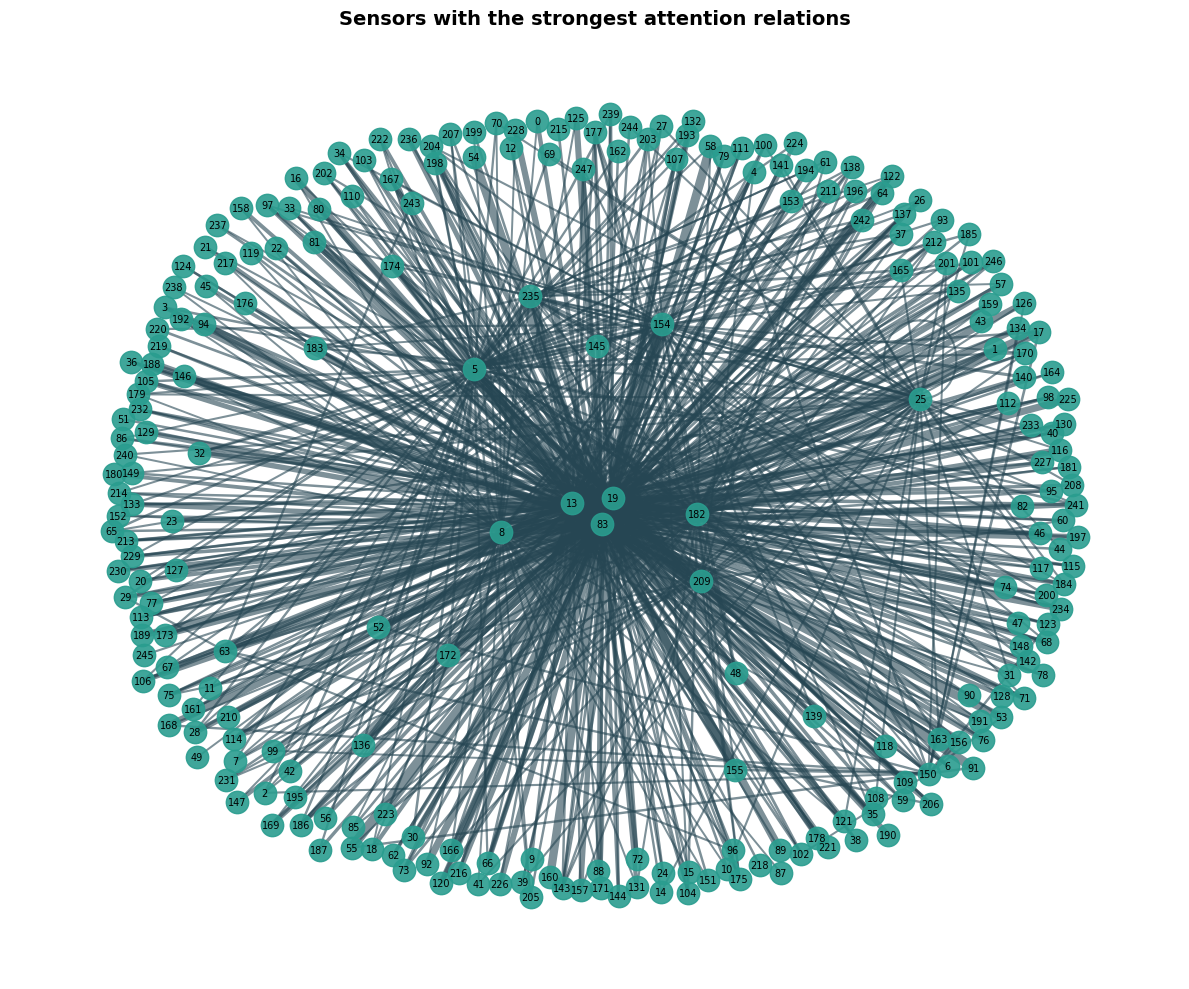

In [ ]:
import numpy as np
import networkx as nx

import matplotlib.pyplot as plt

# Extract top sensor relations from mean attention maps
def get_top_relations(attention_map, top_k=20):
    """Extract top-k attention relations from the attention map."""
    flat_indices = np.argsort(attention_map.flatten())[-top_k:]
    relations = np.unravel_index(flat_indices, attention_map.shape)
    values = attention_map[relations]
    return list(zip(relations[0], relations[1], values))

# Build graph with top relations from all classes
G = nx.DiGraph()
edge_weights = {}

for label in sorted_labels:
    top_relations = get_top_relations(mean_maps[label], top_k=248)
    for src, dst, weight in top_relations:
        edge_id = (src, dst)
        if edge_id in edge_weights:
            edge_weights[edge_id] += weight
        else:
            edge_weights[edge_id] = weight
        G.add_edge(src, dst, weight=weight)

# Filter to top edges by accumulated weight
top_edges = sorted(edge_weights.items(), key=lambda x: x[1], reverse=True)
# G_top = nx.DiGraph()
# for (src, dst), weight in top_edges:
#     G_top.add_edge(src, dst, weight=weight)

# # Visualize
# plt.figure(figsize=(12, 10))
# pos = nx.spring_layout(G_top, k=2, iterations=50, seed=42)

# Draw edges with weights as thickness
# edges = G_top.edges()
# weights = [G_top[u][v]['weight'] for u, v in edges]
# weights_normalized = (np.array(weights) - min(weights)) / (max(weights) - min(weights)) + 0.5

# nx.draw_networkx_edges(G_top, pos, width=weights_normalized*2, alpha=0.6, 
#                        edge_color='gray', arrows=True, arrowsize=5)

# # Draw nodes
# nx.draw_networkx_nodes(G_top, pos, node_color='lightblue', 
#                        node_size=300, edgecolors='black', linewidths=0.2)

# # Draw labels
# nx.draw_networkx_labels(G_top, pos, font_size=8, font_weight='bold')

# plt.title("Top Sensor Relations Network", fontsize=14, fontweight='bold')
# plt.axis('off')
# plt.tight_layout()
# plt.savefig("results/sensor_relations_network.png", dpi=150, bbox_inches='tight')
# plt.show()
# print("Saved → sensor_relations_network.png")

graph = nx.Graph()
graph.add_nodes_from(range(mean_maps[sorted_labels[0]].shape[0]))  # assuming all maps have same shape
graph.add_weighted_edges_from([(src, dst, weight) for (src, dst), weight in edge_weights.items()])


focus_nodes = sorted(set([src for (src, dst), _ in top_edges] + [dst for (src, dst), _ in top_edges]))
subgraph = graph.subgraph(focus_nodes).copy()

plt.figure(figsize=(12, 10))
positions = nx.spring_layout(subgraph, seed=42, k=0.8)
edge_widths = [1.0 + 6.0 * subgraph[u][v]["weight"] for u, v in subgraph.edges()]
nx.draw_networkx_nodes(subgraph, positions, node_size=260, node_color="#2a9d8f", alpha=0.9)
nx.draw_networkx_edges(subgraph, positions, width=edge_widths, alpha=0.6, edge_color="#264653")
nx.draw_networkx_labels(subgraph, positions, font_size=7, font_color="black")
plt.title("Sensors with the strongest attention relations", fontsize=14, fontweight='bold')
plt.axis("off")
plt.tight_layout()
plt.show()

Top sensor relations:
  sensor 19 -> sensor 83: 0.3093
  sensor 17 -> sensor 83: 0.3049
  sensor 55 -> sensor 83: 0.2856
  sensor 54 -> sensor 83: 0.2855
  sensor 58 -> sensor 83: 0.2569
  sensor 53 -> sensor 83: 0.2275
  sensor 52 -> sensor 83: 0.2263
  sensor 16 -> sensor 83: 0.1833
  sensor 77 -> sensor 83: 0.1638
  sensor 81 -> sensor 83: 0.1608
  sensor 36 -> sensor 83: 0.1568
  sensor 66 -> sensor 83: 0.1561
  sensor 72 -> sensor 83: 0.1550
  sensor 30 -> sensor 83: 0.1511
  sensor 76 -> sensor 83: 0.1508
  sensor 28 -> sensor 83: 0.1506
  sensor 32 -> sensor 83: 0.1506
  sensor 46 -> sensor 83: 0.1458
  sensor 29 -> sensor 83: 0.1445
  sensor 80 -> sensor 83: 0.1438
  sensor 82 -> sensor 83: 0.1427
  sensor 26 -> sensor 83: 0.1409
  sensor 20 -> sensor 83: 0.1404
  sensor 64 -> sensor 83: 0.1377
  sensor 35 -> sensor 83: 0.1341
  sensor 3 -> sensor 83: 0.1337
  sensor 5 -> sensor 83: 0.1318
  sensor 18 -> sensor 83: 0.1287
  sensor 0 -> sensor 83: 0.1262
  sensor 68 -> sensor 83

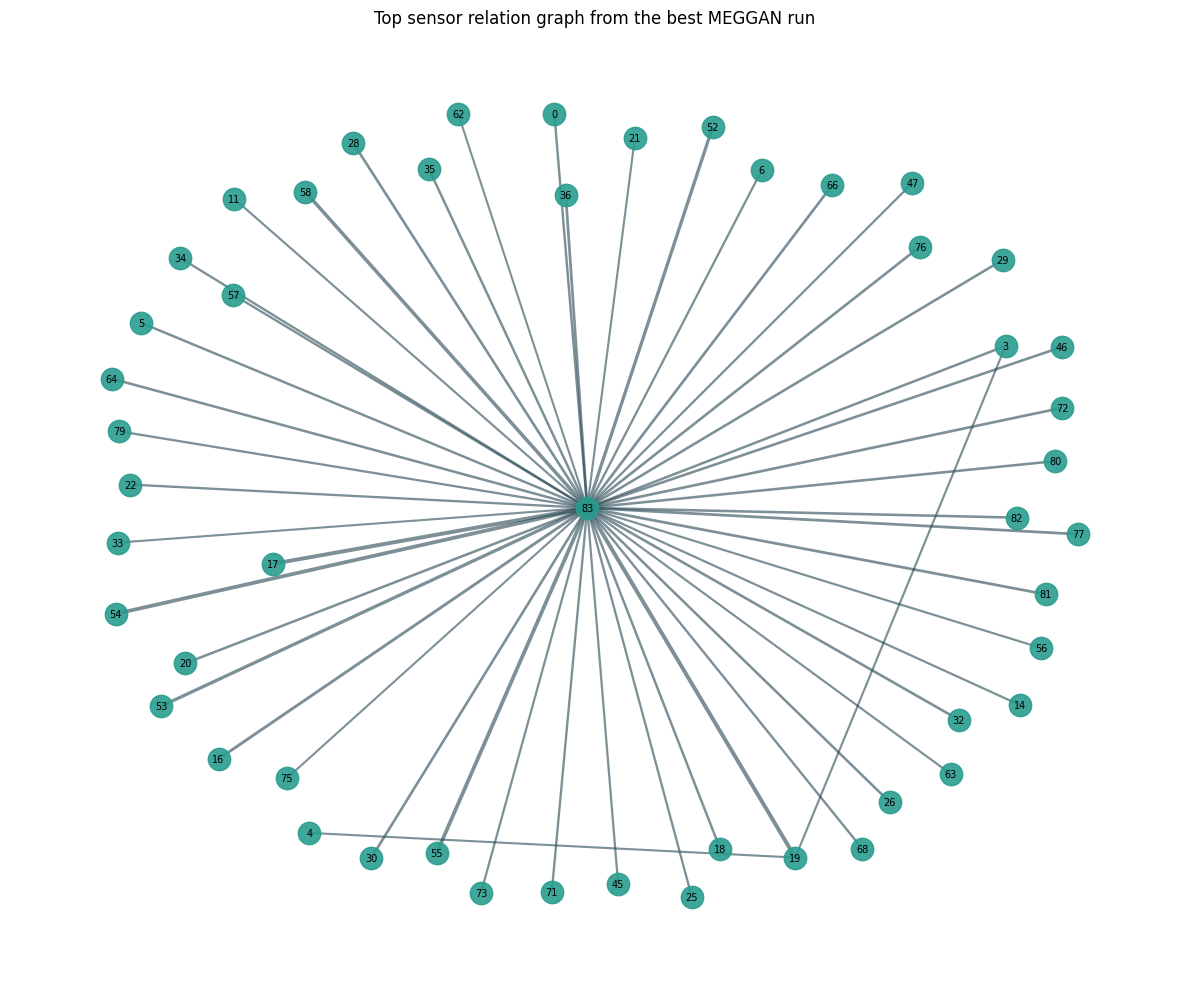

In [26]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

try:
    import networkx as nx
except ImportError:
    nx = None


@torch.no_grad()
def extract_attention_matrix(source_model, loader, device, max_batches=None):
    source_model.eval()
    attention_block = source_model.sensor_attention

    aggregated_attention = None
    sample_count = 0

    for batch_index, batch in enumerate(loader):
        if max_batches is not None and batch_index >= max_batches:
            break

        if len(batch) == 2:
            x, _ = batch
        else:
            x, _, _ = batch

        x = x.to(device)
        node_features = source_model.sensor_encoder(x)
        batch_size, num_nodes, _ = node_features.shape

        query = attention_block.query(node_features).reshape(
            batch_size,
            num_nodes,
            attention_block.num_heads,
            attention_block.head_dim,
        )
        key = attention_block.key(node_features).reshape(
            batch_size,
            num_nodes,
            attention_block.num_heads,
            attention_block.head_dim,
        )

        query = query.permute(0, 2, 1, 3)
        key = key.permute(0, 2, 1, 3)

        attention_logits = torch.matmul(query, key.transpose(-1, -2))
        attention_logits = attention_logits / (attention_block.head_dim ** 0.5)
        attention = torch.softmax(attention_logits, dim=-1)

        mean_attention = attention.mean(dim=1)

        if aggregated_attention is None:
            aggregated_attention = mean_attention.sum(dim=0)
        else:
            aggregated_attention += mean_attention.sum(dim=0)

        sample_count += batch_size

    return (aggregated_attention / sample_count).cpu().numpy()


def plot_sensor_relations(attention_matrix, top_k=40):
    num_sensors = attention_matrix.shape[0]
    upper_row_idx, upper_col_idx = np.triu_indices(num_sensors, k=1)
    edge_weights = attention_matrix[upper_row_idx, upper_col_idx]

    if top_k > len(edge_weights):
        top_k = len(edge_weights)

    top_positions = np.argpartition(edge_weights, -top_k)[-top_k:]
    top_edges = sorted(
        [
            (int(upper_row_idx[position]), int(upper_col_idx[position]), float(edge_weights[position]))
            for position in top_positions
        ],
        key=lambda item: item[2],
        reverse=True,
    )

    print("Top sensor relations:")
    for source_sensor, target_sensor, weight in top_edges:
        print(f"  sensor {source_sensor} -> sensor {target_sensor}: {weight:.4f}")

    if nx is None:
        return

    graph = nx.Graph()
    graph.add_nodes_from(range(num_sensors))
    graph.add_weighted_edges_from(top_edges)

    if graph.number_of_edges() == 0:
        return

    focus_nodes = sorted({node for edge in top_edges for node in edge[:2]})
    subgraph = graph.subgraph(focus_nodes).copy()

    plt.figure(figsize=(12, 10))
    positions = nx.spring_layout(subgraph, seed=42, k=0.8)
    edge_widths = [1.0 + 6.0 * subgraph[u][v]["weight"] for u, v in subgraph.edges()]
    nx.draw_networkx_nodes(subgraph, positions, node_size=260, node_color="#2a9d8f", alpha=0.9)
    nx.draw_networkx_edges(subgraph, positions, width=edge_widths, alpha=0.6, edge_color="#264653")
    nx.draw_networkx_labels(subgraph, positions, font_size=7, font_color="black")
    plt.title("Top sensor relation graph from the best MEGGAN run")
    plt.axis("off")
    plt.tight_layout()
    plt.show()


reference_model = globals().get("best_model", model)
attention_matrix = extract_attention_matrix(reference_model, cross_test_loader, DEVICE, max_batches=4)
plot_sensor_relations(attention_matrix, top_k=50)